In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('loan_data.csv')
print("Starting shape:", df.shape)

print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Drop only physically impossible ages (max verified human lifespan ~122)
print("\nRows with age > 122:")
print(df[df['person_age'] > 122][['person_age','person_emp_exp']])
df = df[df['person_age'] <= 122].copy()
print("Shape after age filter:", df.shape)

# Income: no cap — checked, smooth right-skewed tail, no evidence of data errors
print("\nIncome summary (unchanged):\n", df['person_income'].describe())

print("\nUnique loan_status values:", df['loan_status'].unique())

df.to_csv('loan_data_step1.csv', index=False)
print("\nSaved loan_data_step1.csv, shape:", df.shape)

Starting shape: (45000, 14)

Missing values per column:
 person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

Duplicate rows: 0

Rows with age > 122:
       person_age  person_emp_exp
81          144.0             125
183         144.0             121
575         123.0             101
747         123.0             100
32297       144.0             124
Shape after age filter: (44995, 14)

Income summary (unchanged):
 count    4.499500e+04
mean     8.015163e+04
std      7.307509e+04
min      8.000000e+03
25%      4.719650e+04
50%  

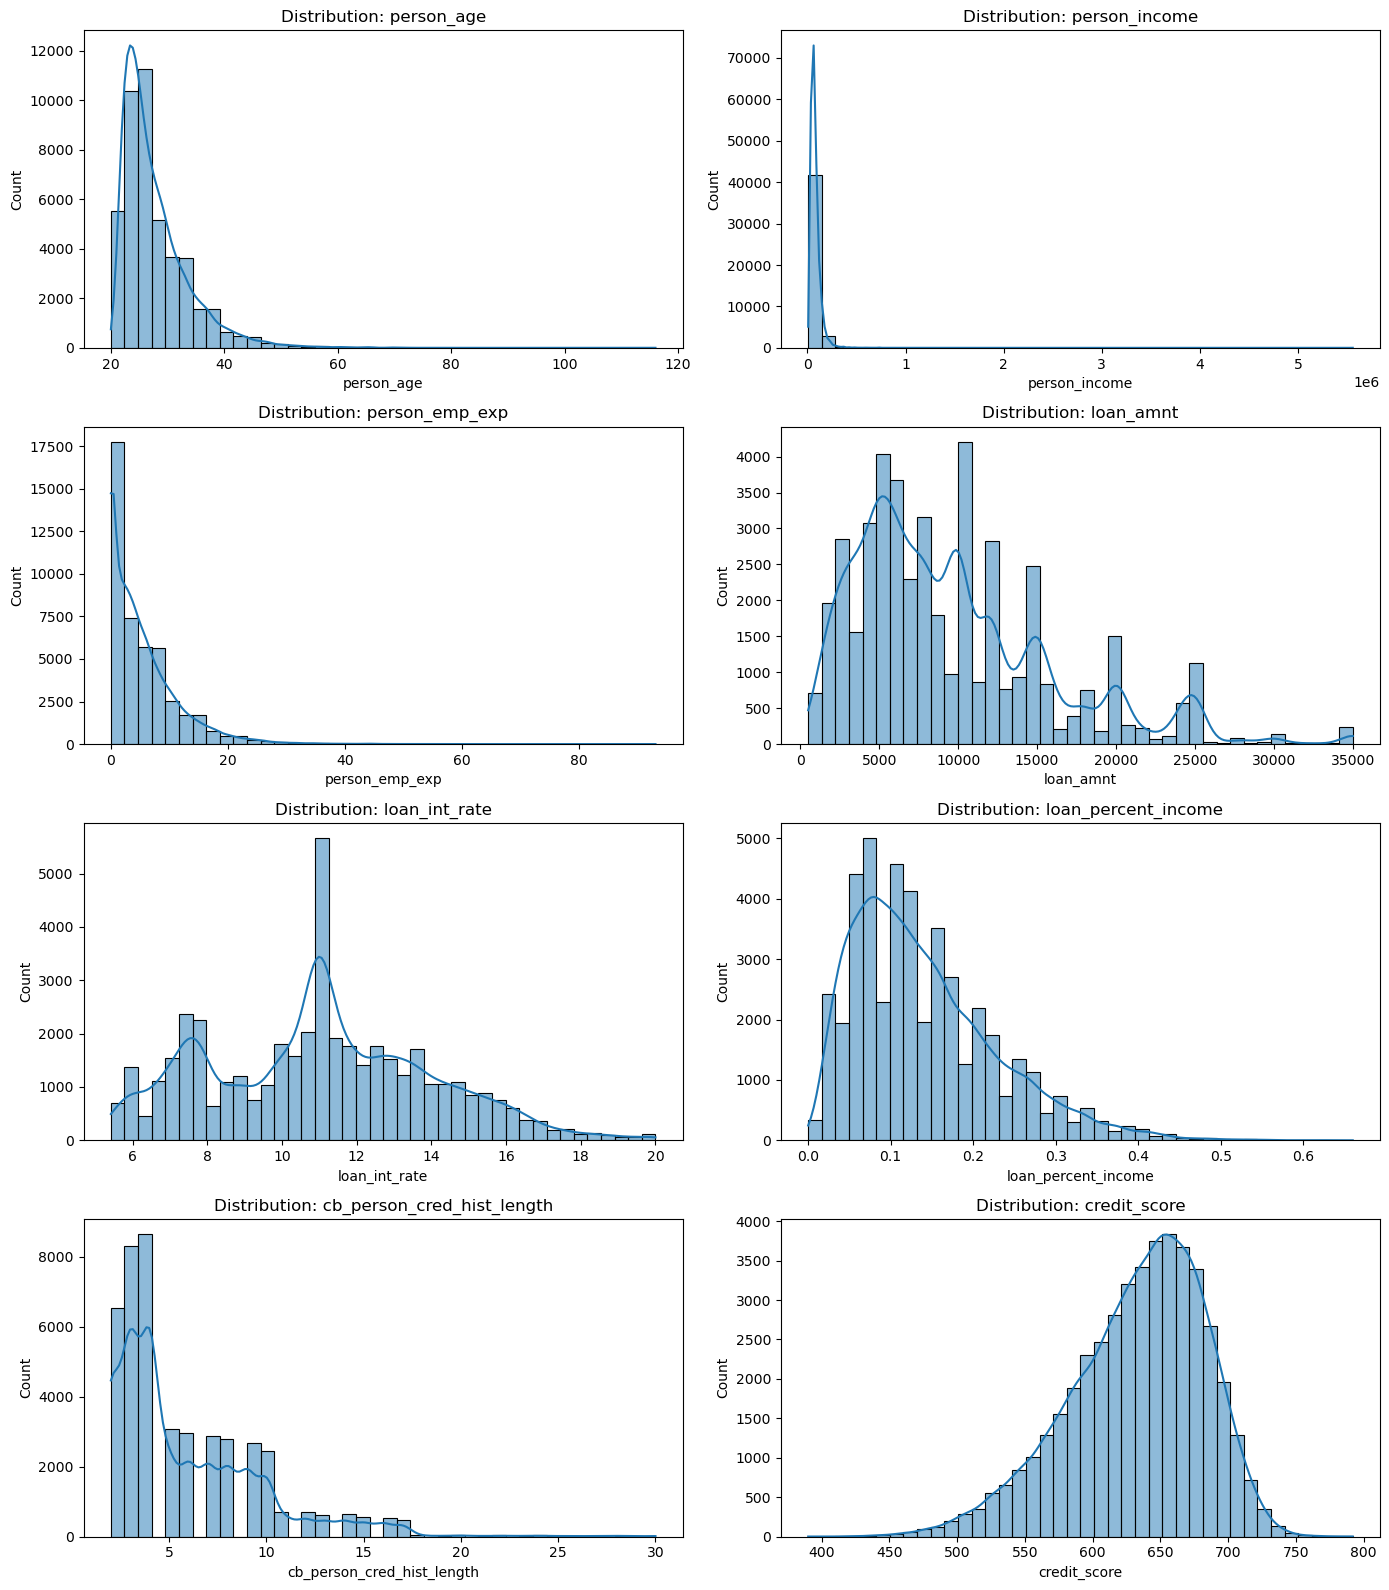

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('loan_data_cleaned.csv')

# ============================================================
# 2a. UNIVARIATE — numeric features
# ============================================================
numeric_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
                 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
                 'credit_score']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=40)
    axes[i].set_title(f'Distribution: {col}')
plt.tight_layout()
plt.savefig('eda_univariate_numeric.png', dpi=120)
plt.show()

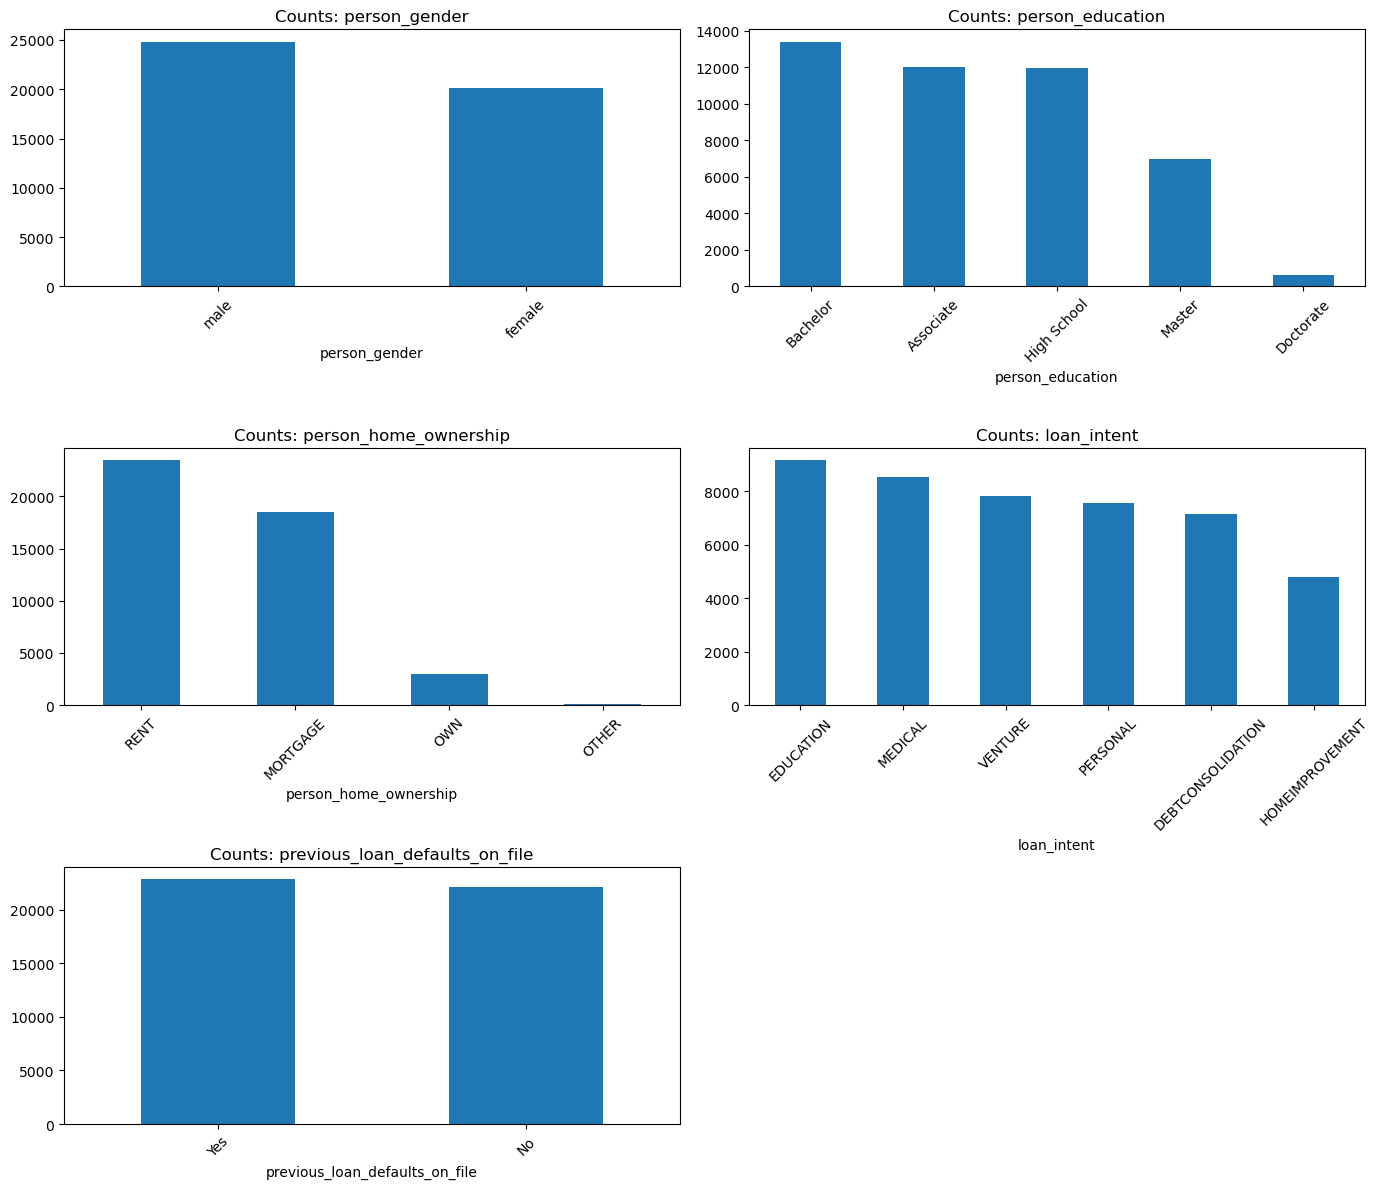

In [4]:
# 2b. UNIVARIATE — categorical features
# ============================================================
categorical_cols = ['person_gender', 'person_education', 'person_home_ownership',
                     'loan_intent', 'previous_loan_defaults_on_file']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Counts: {col}')
    axes[i].tick_params(axis='x', rotation=45)
fig.delaxes(axes[5])  # only 5 categorical cols
plt.tight_layout()
plt.savefig('eda_univariate_categorical.png', dpi=120)
plt.show()

In [5]:
for col in categorical_cols:
    print(f"\n{col}:\n{df[col].value_counts()}")



person_gender:
person_gender
male      24838
female    20157
Name: count, dtype: int64

person_education:
person_education
Bachelor       13397
Associate      12026
High School    11971
Master          6980
Doctorate        621
Name: count, dtype: int64

person_home_ownership:
person_home_ownership
RENT        23440
MORTGAGE    18487
OWN          2951
OTHER         117
Name: count, dtype: int64

loan_intent:
loan_intent
EDUCATION            9151
MEDICAL              8548
VENTURE              7817
PERSONAL             7551
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

previous_loan_defaults_on_file:
previous_loan_defaults_on_file
Yes    22856
No     22139
Name: count, dtype: int64


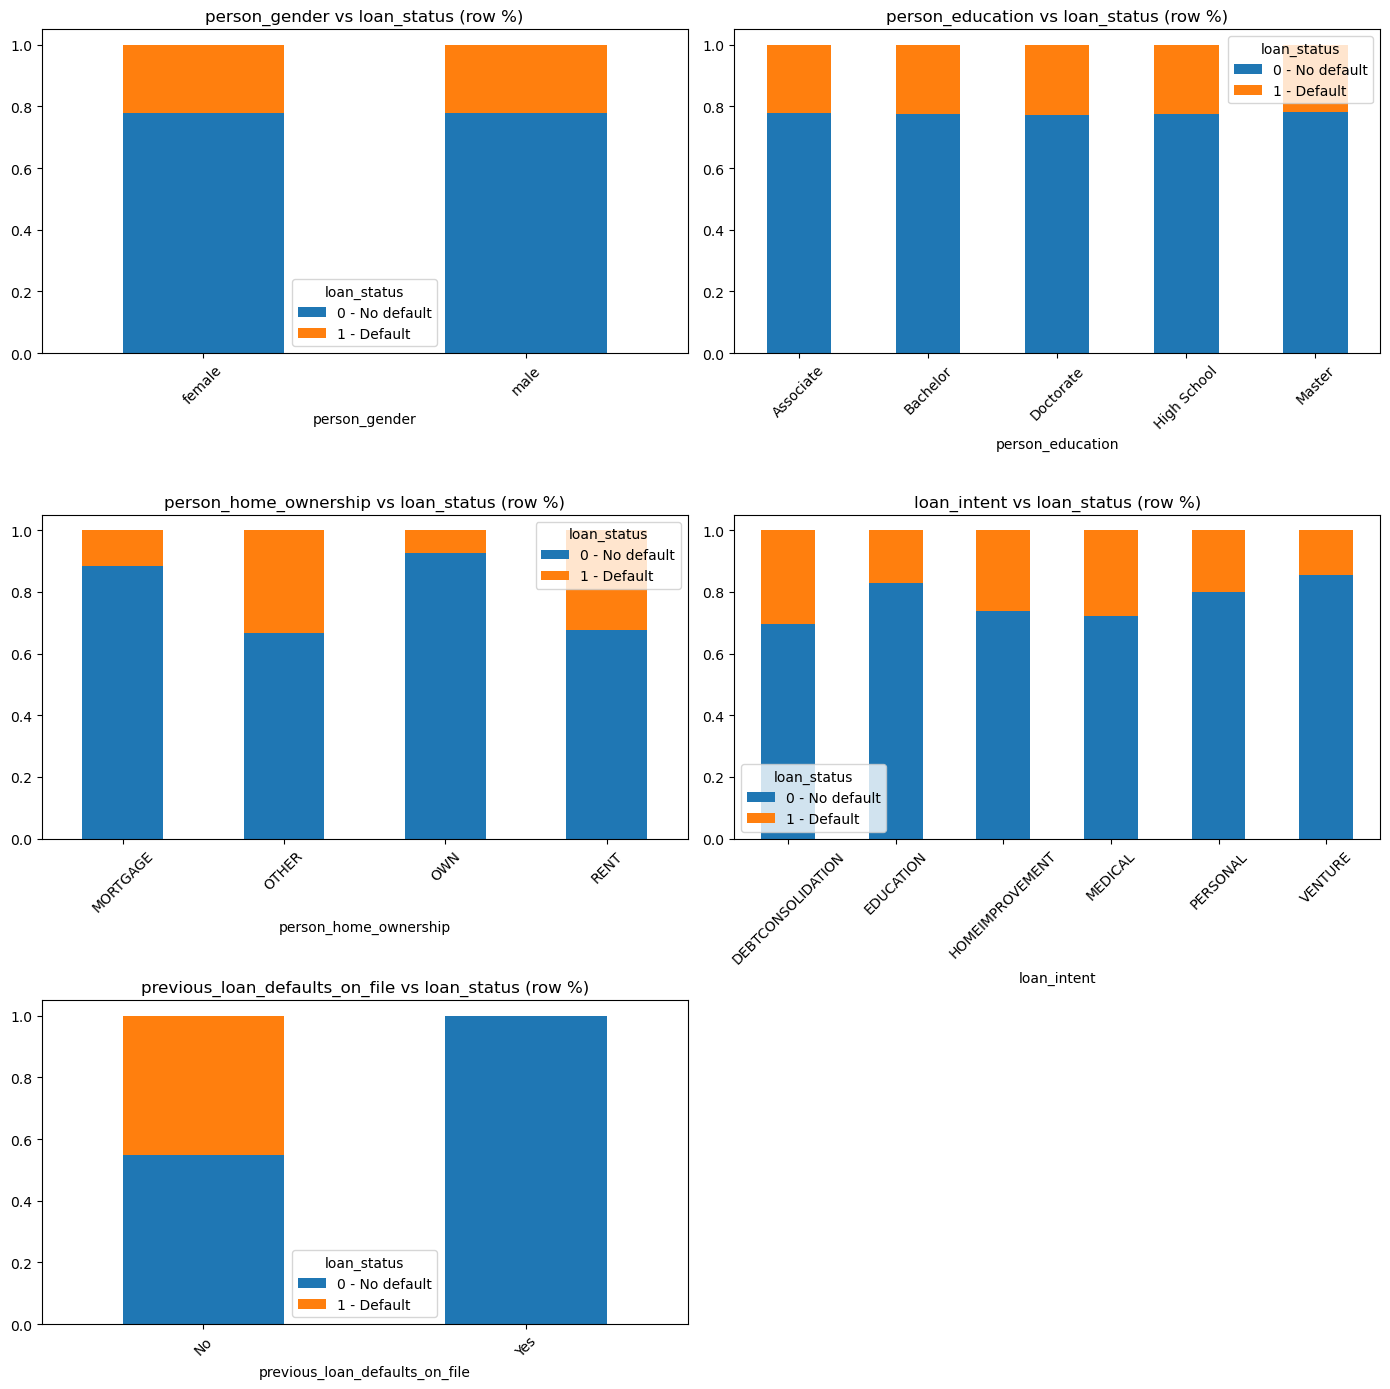


Default rate by person_gender:
person_gender
female    0.222503
male      0.222039
Name: loan_status, dtype: float64

Default rate by person_education:
person_education
Doctorate      0.228663
Bachelor       0.225274
High School    0.223123
Associate      0.220356
Master         0.217622
Name: loan_status, dtype: float64

Default rate by person_home_ownership:
person_home_ownership
OTHER       0.333333
RENT        0.324019
MORTGAGE    0.115973
OWN         0.075229
Name: loan_status, dtype: float64

Default rate by loan_intent:
loan_intent
DEBTCONSOLIDATION    0.302729
MEDICAL              0.278194
HOMEIMPROVEMENT      0.263015
PERSONAL             0.201430
EDUCATION            0.169599
VENTURE              0.144301
Name: loan_status, dtype: float64

Default rate by previous_loan_defaults_on_file:
previous_loan_defaults_on_file
No     0.451692
Yes    0.000000
Name: loan_status, dtype: float64


In [6]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['loan_status'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f'{col} vs loan_status (row %)')
    axes[i].legend(title='loan_status', labels=['0 - No default', '1 - Default'])
    axes[i].tick_params(axis='x', rotation=45)
fig.delaxes(axes[5])
plt.tight_layout()
plt.savefig('eda_bivariate_categorical.png', dpi=120)
plt.show()

for col in categorical_cols:
    print(f"\nDefault rate by {col}:")
    print(df.groupby(col)['loan_status'].mean().sort_values(ascending=False))


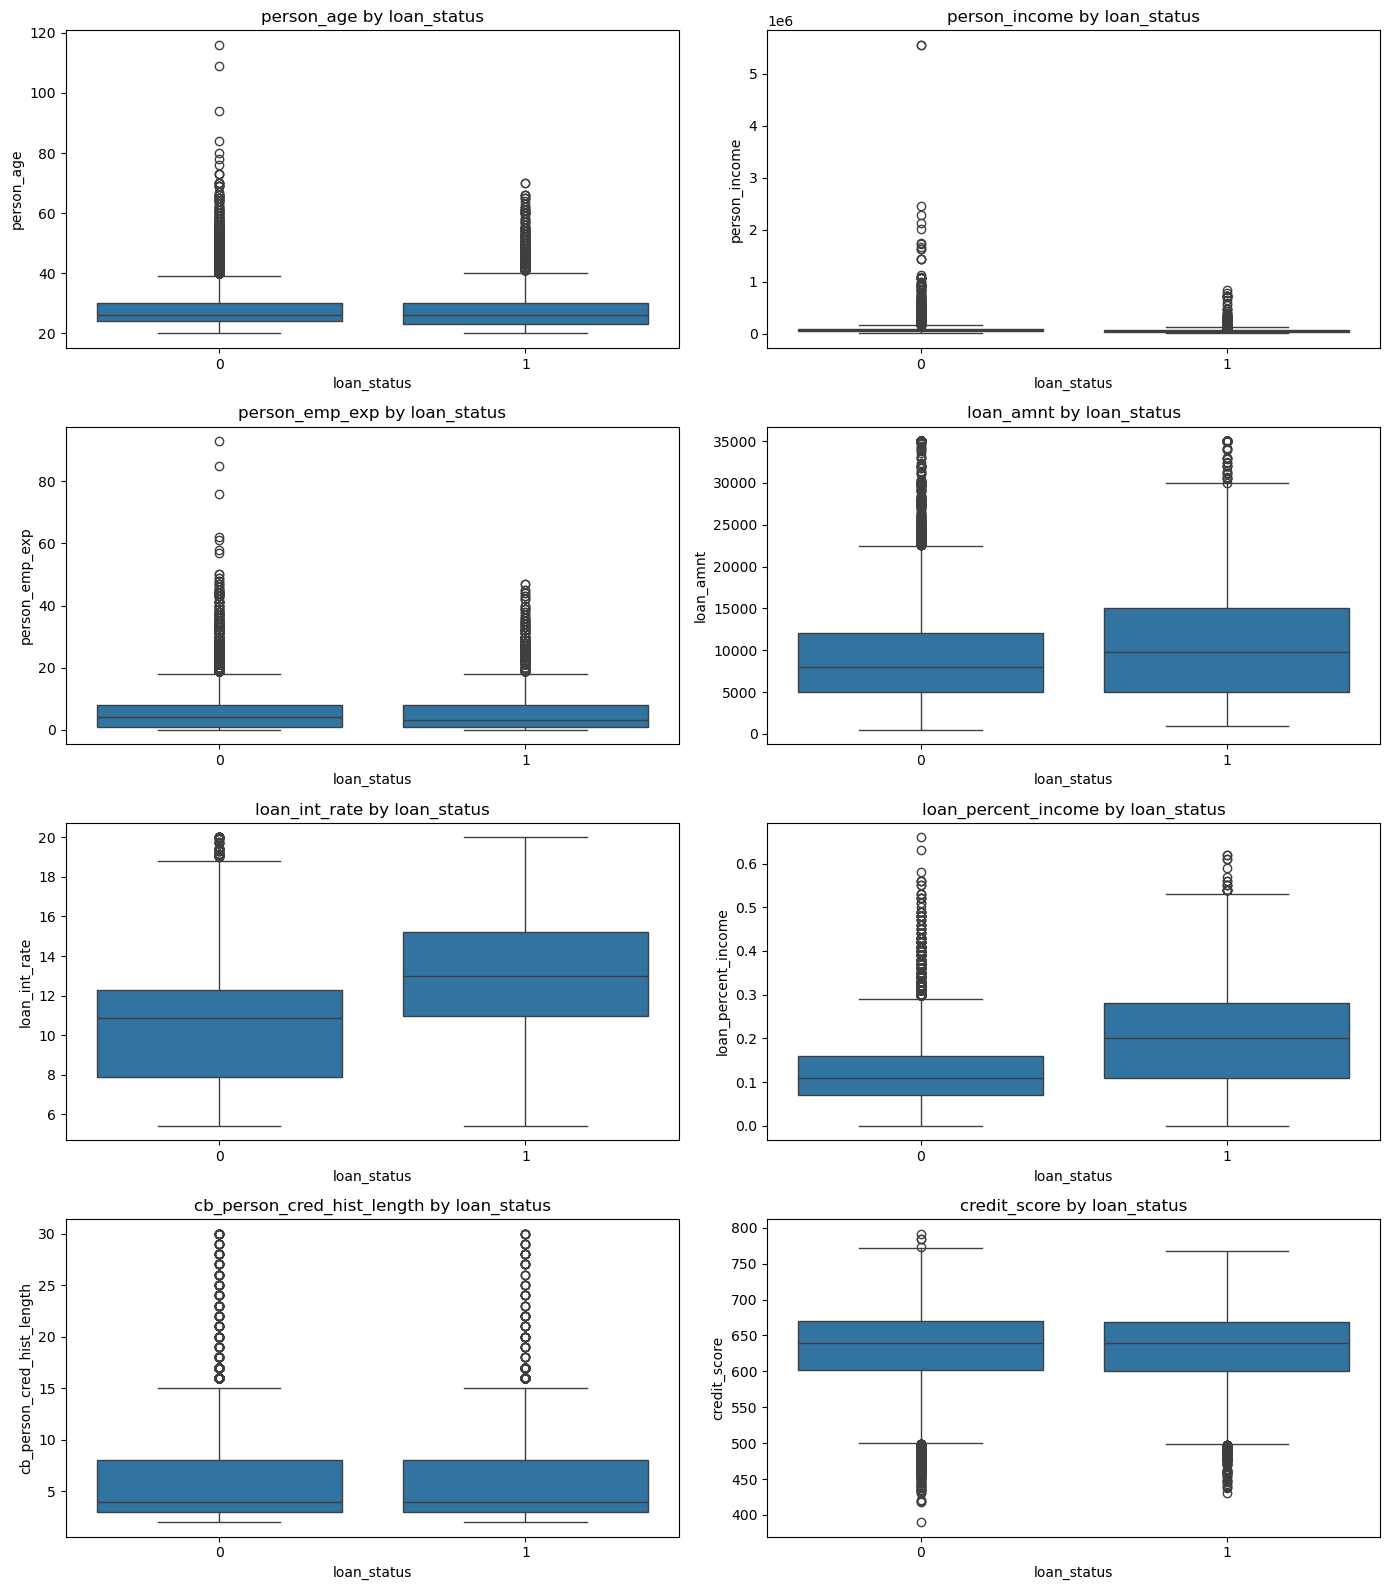


Median numeric values by loan_status:
             person_age  person_income  person_emp_exp  loan_amnt  \
loan_status                                                         
0                  26.0        72927.0             4.0     8000.0   
1                  26.0        50629.0             3.0     9750.0   

             loan_int_rate  loan_percent_income  cb_person_cred_hist_length  \
loan_status                                                                   
0                    10.85                 0.11                         4.0   
1                    12.98                 0.20                         4.0   

             credit_score  
loan_status                
0                   640.0  
1                   639.0  


In [7]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='loan_status', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} by loan_status')
plt.tight_layout()
plt.savefig('eda_bivariate_numeric.png', dpi=120)
plt.show()

print("\nMedian numeric values by loan_status:")
print(df.groupby('loan_status')[numeric_cols].median())

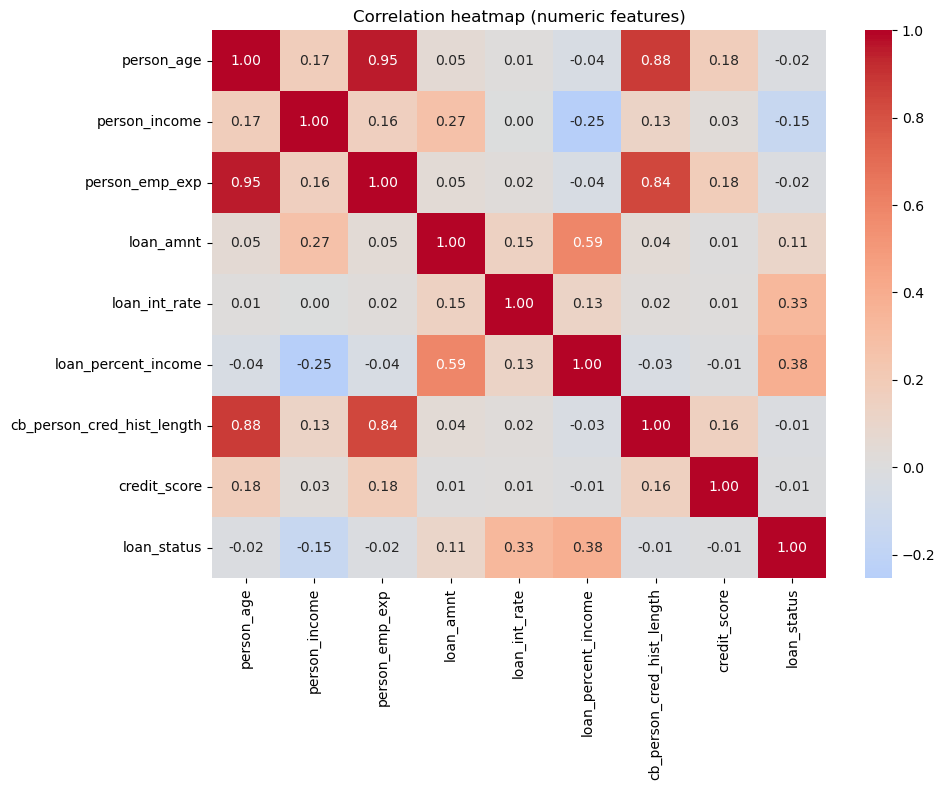


Correlation with loan_status, sorted:
loan_status                   1.000000
loan_percent_income           0.384887
loan_int_rate                 0.332032
loan_amnt                     0.107740
credit_score                 -0.007463
cb_person_cred_hist_length   -0.014832
person_emp_exp               -0.019777
person_age                   -0.020791
person_income                -0.148249
Name: loan_status, dtype: float64


In [8]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols + ['loan_status']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap (numeric features)')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=120)
plt.show()

print("\nCorrelation with loan_status, sorted:")
print(corr['loan_status'].sort_values(ascending=False))

In [9]:
import pandas as pd
from scipy.stats import chi2_contingency, mannwhitneyu, normaltest, skew
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

df = pd.read_csv('loan_data_step1.csv')

# Drop leakage column — previous_loan_defaults_on_file='Yes' had ZERO exceptions
# across 22,858 rows (perfect deterministic relationship with target = target leakage)
df = df.drop(columns=['previous_loan_defaults_on_file'])
df.to_csv('loan_data_step3.csv', index=False)
print("Dropped leakage column. Shape:", df.shape)

numeric_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
                 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
categorical_cols = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent']

# Normality check first (justifies Mann-Whitney over t-test)
print("\n=== Normality check ===")
for col in numeric_cols:
    stat, p = normaltest(df[col])
    print(f"{col:30s} skew={skew(df[col]):6.2f}  p={p:.3e}  normal={p>=0.05}")

print("\n=== Mann-Whitney U test ===")
g0, g1 = df[df['loan_status']==0], df[df['loan_status']==1]
for col in numeric_cols:
    stat, p = mannwhitneyu(g0[col], g1[col], alternative='two-sided')
    print(f"{col:30s} p={p:.3e}  significant={p<0.05}")

print("\n=== Chi-square test ===")
for col in categorical_cols:
    ct = pd.crosstab(df[col], df['loan_status'])
    chi2, p, dof, exp = chi2_contingency(ct)
    print(f"{col:30s} chi2={chi2:8.2f}  p={p:.3e}  significant={p<0.05}")

# VIF on the numeric predictors
X_vif = add_constant(df[numeric_cols])
vif_data = pd.DataFrame({'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]})
print("\n=== VIF ===")
print(vif_data[vif_data['feature']!='const'].sort_values('VIF', ascending=False))
print("\nperson_age and person_emp_exp both flagged (corr=0.95) -> drop person_age next step.")

Dropped leakage column. Shape: (44995, 13)

=== Normality check ===
person_age                     skew=  2.01  p=0.000e+00  normal=False
person_income                  skew= 24.95  p=0.000e+00  normal=False
person_emp_exp                 skew=  2.05  p=0.000e+00  normal=False
loan_amnt                      skew=  1.18  p=0.000e+00  normal=False
loan_int_rate                  skew=  0.21  p=1.679e-191  normal=False
loan_percent_income            skew=  1.03  p=0.000e+00  normal=False
cb_person_cred_hist_length     skew=  1.63  p=0.000e+00  normal=False
credit_score                   skew= -0.61  p=0.000e+00  normal=False

=== Mann-Whitney U test ===
person_age                     p=1.336e-10  significant=True
person_income                  p=0.000e+00  significant=True
person_emp_exp                 p=7.637e-09  significant=True
loan_amnt                      p=1.221e-75  significant=True
loan_int_rate                  p=0.000e+00  significant=True
loan_percent_income            p=0.00

In [10]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('loan_data_step3.csv')
df = df.drop(columns=['person_age'])  # proven redundant via VIF, not a "selection" question

categorical_cols = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=['loan_status'])
y = df_encoded['loan_status']
X = X.astype({c: int for c in X.columns if X[c].dtype == bool})
print("Full feature set going into selection:", X.shape[1], "features")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.to_csv('X_train_scaled_full.csv', index=False)
X_test_scaled.to_csv('X_test_scaled_full.csv', index=False)
X_train.to_csv('X_train_raw_full.csv', index=False)
X_test.to_csv('X_test_raw_full.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
print("Saved full (unselected) feature sets — Step 4.5 will trim these down.")

Full feature set going into selection: 20 features
Saved full (unselected) feature sets — Step 4.5 will trim these down.


In [11]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression, LassoCV

X_train_scaled = pd.read_csv('X_train_scaled_full.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
feature_names = X_train_scaled.columns.tolist()

# ============================================================
# Method 1: SelectKBest (univariate statistical test — ANOVA F-score)
# Scores each feature independently against the target, no model involved.
# ============================================================
skb = SelectKBest(score_func=f_classif, k='all').fit(X_train_scaled, y_train)
skb_scores = pd.DataFrame({'feature': feature_names, 'f_score': skb.scores_, 'p_value': skb.pvalues_})
skb_scores = skb_scores.sort_values('f_score', ascending=False)
print("=== Method 1: SelectKBest (ANOVA F-test) ===")
print(skb_scores.to_string(index=False))

# ============================================================
# Method 2: RFE (Recursive Feature Elimination) using Logistic Regression
# Iteratively trains a model, removes the weakest feature, repeats.
# ============================================================
rfe_estimator = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=10)  # keep top 10
rfe.fit(X_train_scaled, y_train)
rfe_results = pd.DataFrame({'feature': feature_names, 'selected': rfe.support_, 'rank': rfe.ranking_})
rfe_results = rfe_results.sort_values('rank')
print("\n=== Method 2: RFE (rank=1 means selected) ===")
print(rfe_results.to_string(index=False))

# ============================================================
# Method 3: Lasso (L1 regularization) — shrinks weak feature coefficients to exactly 0
# ============================================================
lasso = LassoCV(cv=5, random_state=42, max_iter=5000).fit(X_train_scaled, y_train)
lasso_coefs = pd.DataFrame({'feature': feature_names, 'lasso_coef': lasso.coef_})
lasso_coefs['selected'] = lasso_coefs['lasso_coef'] != 0
lasso_coefs = lasso_coefs.sort_values('lasso_coef', key=abs, ascending=False)
print("\n=== Method 3: Lasso (coefficient=0 means dropped) ===")
print(lasso_coefs.to_string(index=False))

# ============================================================
# Consensus table — combine all 3 methods
# ============================================================
consensus = pd.DataFrame({'feature': feature_names})
consensus = consensus.merge(skb_scores[['feature','f_score','p_value']], on='feature')
consensus['skb_significant'] = consensus['p_value'] < 0.05
consensus = consensus.merge(rfe_results[['feature','selected']].rename(columns={'selected':'rfe_selected'}), on='feature')
consensus = consensus.merge(lasso_coefs[['feature','selected']].rename(columns={'selected':'lasso_selected'}), on='feature')
consensus['votes'] = consensus[['skb_significant','rfe_selected','lasso_selected']].sum(axis=1)
consensus = consensus.sort_values('votes', ascending=False)

print("\n=== CONSENSUS TABLE (votes out of 3 methods) ===")
print(consensus[['feature','votes','skb_significant','rfe_selected','lasso_selected']].to_string(index=False))

# Keep any feature that at least 2 of 3 methods agree on
final_features = consensus[consensus['votes'] >= 2]['feature'].tolist()
print(f"\nFeatures kept (2+/3 votes): {len(final_features)}")
print(final_features)
print(f"\nFeatures dropped (0-1/3 votes): {len(feature_names) - len(final_features)}")
print([f for f in feature_names if f not in final_features])

pd.Series(final_features).to_csv('selected_features.csv', index=False)
print("\nSaved selected_features.csv")

=== Method 1: SelectKBest (ANOVA F-test) ===
                     feature     f_score       p_value
         loan_percent_income 6271.572664  0.000000e+00
               loan_int_rate 4587.355354  0.000000e+00
  person_home_ownership_RENT 2521.809663  0.000000e+00
               person_income  737.033636 1.105964e-160
                   loan_amnt  427.407245  2.110936e-94
   person_home_ownership_OWN  309.248338  6.189538e-69
         loan_intent_VENTURE  296.216289  4.047062e-66
         loan_intent_MEDICAL  170.591351  6.738153e-39
       loan_intent_EDUCATION  154.606566  2.018349e-35
 loan_intent_HOMEIMPROVEMENT   41.709615  1.072347e-10
        loan_intent_PERSONAL   17.976507  2.242055e-05
              person_emp_exp   12.163477  4.879258e-04
 person_home_ownership_OTHER   10.204722  1.402022e-03
  cb_person_cred_hist_length    9.911478  1.643853e-03
   person_education_Bachelor    2.745335  9.754736e-02
          person_gender_male    1.047606  3.060659e-01
     person_educatio

In [4]:
import pandas as pd
from imblearn.over_sampling import SMOTE

# Fixed: read without header=None, so pandas correctly treats the first row as the header
selected_features = pd.read_csv('selected_features.csv')['0'].tolist()
print("Selected features loaded:", selected_features)

X_train_scaled = pd.read_csv('X_train_scaled_full.csv')[selected_features]
X_test_scaled = pd.read_csv('X_test_scaled_full.csv')[selected_features]
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

X_train_scaled.to_csv('X_train_scaled.csv', index=False)
X_test_scaled.to_csv('X_test_scaled.csv', index=False)
print("Trimmed to", X_train_scaled.shape[1], "selected features")

print("\nBefore SMOTE:\n", y_train.value_counts())
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
print("\nAfter SMOTE:\n", y_train_bal.value_counts())

X_train_bal.to_csv('X_train_smote.csv', index=False)
y_train_bal.to_csv('y_train_smote.csv', index=False)
print("\nSaved X_train_smote.csv, y_train_smote.csv")

Selected features loaded: ['person_income', 'person_home_ownership_OWN', 'loan_intent_PERSONAL', 'loan_intent_MEDICAL', 'loan_intent_EDUCATION', 'person_home_ownership_RENT', 'loan_intent_VENTURE', 'loan_percent_income', 'loan_int_rate', 'loan_amnt', 'person_emp_exp', 'person_home_ownership_OTHER', 'cb_person_cred_hist_length', 'loan_intent_HOMEIMPROVEMENT']
Trimmed to 14 selected features

Before SMOTE:
 loan_status
0    27996
1     8000
Name: count, dtype: int64

After SMOTE:
 loan_status
0    27996
1    27996
Name: count, dtype: int64

Saved X_train_smote.csv, y_train_smote.csv


In [5]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import joblib

X_train_scaled = pd.read_csv('X_train_scaled.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
X_train_smote = pd.read_csv('X_train_smote.csv')
y_train_smote = pd.read_csv('y_train_smote.csv').squeeze()

models = {}

print("Training SMOTE-balanced models...")
models['LogReg_SMOTE'] = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_smote, y_train_smote)
print(" - Logistic Regression done")

models['RF_SMOTE'] = RandomForestClassifier(random_state=42, n_jobs=-1).fit(X_train_smote, y_train_smote)
print(" - Random Forest done")

svm_idx = X_train_smote.sample(n=10000, random_state=42).index
models['SVM_SMOTE'] = SVC(probability=True, random_state=42, kernel='rbf').fit(
    X_train_smote.loc[svm_idx], y_train_smote.loc[svm_idx])
print(" - SVM done (10,000-row subsample)")

models['KNN_SMOTE'] = KNeighborsClassifier(n_neighbors=5).fit(X_train_smote, y_train_smote)
print(" - KNN done")

models['XGB_SMOTE'] = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1).fit(X_train_smote, y_train_smote)
print(" - XGBoost done")

print("\nTraining class_weight='balanced' models...")
models['LogReg_ClassWeight'] = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42).fit(X_train_scaled, y_train)
print(" - Logistic Regression done")

models['RF_ClassWeight'] = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1).fit(X_train_scaled, y_train)
print(" - Random Forest done")

svm_idx2 = X_train_scaled.sample(n=10000, random_state=42).index
models['SVM_ClassWeight'] = SVC(probability=True, class_weight='balanced', random_state=42, kernel='rbf').fit(
    X_train_scaled.loc[svm_idx2], y_train.loc[svm_idx2])
print(" - SVM done (10,000-row subsample)")

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f" - XGBoost scale_pos_weight = {scale_pos_weight:.3f}")
models['XGB_ClassWeight'] = XGBClassifier(
    random_state=42, eval_metric='logloss', n_jobs=-1, scale_pos_weight=scale_pos_weight
).fit(X_train_scaled, y_train)
print(" - XGBoost done")

joblib.dump(models, 'trained_models.pkl')
print(f"\nSaved {len(models)} trained models: {list(models.keys())}")

Training SMOTE-balanced models...
 - Logistic Regression done
 - Random Forest done
 - SVM done (10,000-row subsample)
 - KNN done
 - XGBoost done

Training class_weight='balanced' models...
 - Logistic Regression done
 - Random Forest done
 - SVM done (10,000-row subsample)
 - XGBoost scale_pos_weight = 3.499
 - XGBoost done

Saved 9 trained models: ['LogReg_SMOTE', 'RF_SMOTE', 'SVM_SMOTE', 'KNN_SMOTE', 'XGB_SMOTE', 'LogReg_ClassWeight', 'RF_ClassWeight', 'SVM_ClassWeight', 'XGB_ClassWeight']


In [6]:
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import joblib

X_train_scaled = pd.read_csv('X_train_scaled.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
X_train_smote = pd.read_csv('X_train_smote.csv')
y_train_smote = pd.read_csv('y_train_smote.csv').squeeze()
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = joblib.load('trained_models.pkl')  # existing 9 untuned models, we ADD tuned versions

def tune(estimator, param_dist, X, y, n_iter=20, label=""):
    search = RandomizedSearchCV(estimator, param_distributions=param_dist, n_iter=n_iter,
                                 scoring='roc_auc', cv=5, random_state=42, n_jobs=-1, verbose=0)
    search.fit(X, y)
    print(f"{label}: best AUC={search.best_score_:.4f}  params={search.best_params_}")
    return search.best_estimator_

# ============================================================
# Logistic Regression
# ============================================================
lr_params = {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
models['LogReg_SMOTE_Tuned'] = tune(LogisticRegression(max_iter=1000, random_state=42),
    lr_params, X_train_smote, y_train_smote, label="LogReg_SMOTE_Tuned")
models['LogReg_ClassWeight_Tuned'] = tune(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    lr_params, X_train_scaled, y_train, label="LogReg_ClassWeight_Tuned")

# ============================================================
# Random Forest
# ============================================================
rf_params = {'n_estimators': [100, 200, 300], 'max_depth': [5, 10, 15, None],
             'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4],
             'max_features': ['sqrt', 'log2']}
models['RF_SMOTE_Tuned'] = tune(RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, X_train_smote, y_train_smote, label="RF_SMOTE_Tuned")
models['RF_ClassWeight_Tuned'] = tune(RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    rf_params, X_train_scaled, y_train, label="RF_ClassWeight_Tuned")

# ============================================================
# SVM — tuned on the SAME 10,000-row subsample used for the untuned version (speed)
# ============================================================
svm_params = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01, 0.1], 'kernel': ['rbf']}
svm_idx = X_train_smote.sample(n=10000, random_state=42).index
models['SVM_SMOTE_Tuned'] = tune(SVC(probability=True, random_state=42),
    svm_params, X_train_smote.loc[svm_idx], y_train_smote.loc[svm_idx], n_iter=10, label="SVM_SMOTE_Tuned")
svm_idx2 = X_train_scaled.sample(n=10000, random_state=42).index
models['SVM_ClassWeight_Tuned'] = tune(SVC(probability=True, class_weight='balanced', random_state=42),
    svm_params, X_train_scaled.loc[svm_idx2], y_train.loc[svm_idx2], n_iter=10, label="SVM_ClassWeight_Tuned")

# ============================================================
# KNN — SMOTE version only (no class_weight equivalent, same as before)
# ============================================================
knn_params = {'n_neighbors': [3, 5, 7, 9, 11, 15], 'weights': ['uniform', 'distance'], 'p': [1, 2]}
models['KNN_SMOTE_Tuned'] = tune(KNeighborsClassifier(),
    knn_params, X_train_smote, y_train_smote, label="KNN_SMOTE_Tuned")

# ============================================================
# XGBoost
# ============================================================
xgb_params = {'n_estimators': [100, 200, 300, 400], 'max_depth': [3, 4, 5, 6, 7],
              'learning_rate': [0.01, 0.05, 0.1, 0.2], 'subsample': [0.7, 0.8, 0.9, 1.0],
              'colsample_bytree': [0.7, 0.8, 0.9, 1.0], 'min_child_weight': [1, 3, 5]}
models['XGB_SMOTE_Tuned'] = tune(XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    xgb_params, X_train_smote, y_train_smote, n_iter=30, label="XGB_SMOTE_Tuned")
models['XGB_ClassWeight_Tuned'] = tune(XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1,
    scale_pos_weight=scale_pos_weight), xgb_params, X_train_scaled, y_train, n_iter=30, label="XGB_ClassWeight_Tuned")

joblib.dump(models, 'trained_models.pkl')
print(f"\nTotal models saved: {len(models)}")
print(list(models.keys()))

C:\Users\Ananya\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 10 is smaller than n_iter=20. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


LogReg_SMOTE_Tuned: best AUC=0.8629  params={'solver': 'liblinear', 'penalty': 'l1', 'C': 0.1}


C:\Users\Ananya\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 10 is smaller than n_iter=20. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


LogReg_ClassWeight_Tuned: best AUC=0.8604  params={'solver': 'liblinear', 'penalty': 'l1', 'C': 0.1}
RF_SMOTE_Tuned: best AUC=0.9817  params={'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
RF_ClassWeight_Tuned: best AUC=0.9296  params={'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
SVM_SMOTE_Tuned: best AUC=0.9004  params={'kernel': 'rbf', 'gamma': 0.1, 'C': 10}
SVM_ClassWeight_Tuned: best AUC=0.8922  params={'kernel': 'rbf', 'gamma': 'auto', 'C': 10}
KNN_SMOTE_Tuned: best AUC=0.9695  params={'weights': 'distance', 'p': 1, 'n_neighbors': 9}
XGB_SMOTE_Tuned: best AUC=0.9820  params={'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
XGB_ClassWeight_Tuned: best AUC=0.9393  params={'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'colsample

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix,
                              precision_score, recall_score, f1_score, accuracy_score)
import joblib

models = joblib.load('trained_models.pkl')
X_test_scaled = pd.read_csv('X_test_scaled.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    results.append({'model': name, 'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred), 'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred), 'roc_auc': roc_auc_score(y_test, y_proba)})

results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
print("=== FULL COMPARISON — all 18 models ===")
print(results_df.to_string(index=False))
results_df.to_csv('model_comparison_results_tuned.csv', index=False)

# --- Tuned vs untuned, side by side, for each model type ---
print("\n=== Tuned vs Untuned improvement ===")
for base in ['LogReg_SMOTE','LogReg_ClassWeight','RF_SMOTE','RF_ClassWeight',
             'SVM_SMOTE','SVM_ClassWeight','KNN_SMOTE','XGB_SMOTE','XGB_ClassWeight']:
    tuned = base + '_Tuned'
    if tuned in results_df['model'].values:
        auc_before = results_df.loc[results_df['model']==base, 'roc_auc'].values[0]
        auc_after = results_df.loc[results_df['model']==tuned, 'roc_auc'].values[0]
        print(f"{base:25s} {auc_before:.4f} -> {auc_after:.4f}  (Δ {auc_after-auc_before:+.4f})")

=== FULL COMPARISON — all 18 models ===
                   model  accuracy  precision  recall       f1  roc_auc
   XGB_ClassWeight_Tuned  0.896655   0.747685  0.8075 0.776442 0.938477
         XGB_ClassWeight  0.892210   0.735806  0.8035 0.768164 0.936084
         XGB_SMOTE_Tuned  0.914213   0.867665  0.7245 0.789646 0.935440
               XGB_SMOTE  0.911212   0.870908  0.7050 0.779221 0.931864
    RF_ClassWeight_Tuned  0.911546   0.908412  0.6695 0.770869 0.930345
          RF_ClassWeight  0.911657   0.910702  0.6680 0.770695 0.929077
          RF_SMOTE_Tuned  0.900767   0.800652  0.7370 0.767508 0.923872
                RF_SMOTE  0.898655   0.796296  0.7310 0.762252 0.923358
         SVM_ClassWeight  0.832426   0.593465  0.7810 0.674439 0.888338
               SVM_SMOTE  0.832648   0.595367  0.7710 0.671895 0.887854
   SVM_ClassWeight_Tuned  0.841205   0.615916  0.7585 0.679812 0.887289
         SVM_SMOTE_Tuned  0.842427   0.619067  0.7565 0.680918 0.886821
         KNN_SMOTE_Tuned

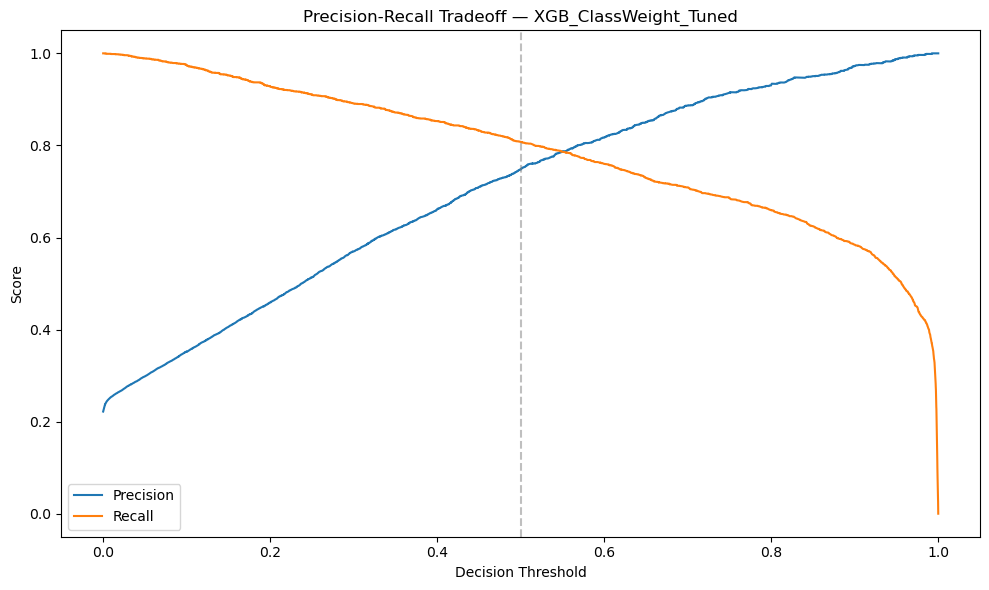

Threshold   Precision   Recall      F1          
0.5         0.748       0.807       0.776       
0.4         0.661       0.853       0.745       
0.35        0.617       0.872       0.723       
0.3         0.570       0.891       0.695       
0.25        0.514       0.910       0.657       
0.2         0.459       0.928       0.614       


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score
import joblib

models = joblib.load('trained_models.pkl')
X_test_scaled = pd.read_csv('X_test_scaled.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

best_model = models['XGB_ClassWeight_Tuned']
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Decision Threshold'); plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff — XGB_ClassWeight_Tuned')
plt.legend(); plt.tight_layout()
plt.savefig('precision_recall_tuned.png', dpi=120); plt.show()

print(f"{'Threshold':<12}{'Precision':<12}{'Recall':<12}{'F1':<12}")
for t in [0.5, 0.4, 0.35, 0.3, 0.25, 0.2]:
    y_pred_t = (y_proba >= t).astype(int)
    print(f"{t:<12}{precision_score(y_test,y_pred_t):<12.3f}{recall_score(y_test,y_pred_t):<12.3f}{f1_score(y_test,y_pred_t):<12.3f}")

In [9]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import joblib

models = joblib.load('trained_models.pkl')
X_test_scaled = pd.read_csv('X_test_scaled.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

best_model = models['XGB_ClassWeight_Tuned']
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

THRESHOLD = 0.35
y_pred_final = (y_proba >= THRESHOLD).astype(int)

print(f"=== FINAL MODEL: XGB_ClassWeight_Tuned, threshold={THRESHOLD} ===\n")
print(classification_report(y_test, y_pred_final, target_names=['No Default','Default']))
print(confusion_matrix(y_test, y_pred_final))

pd.DataFrame({'y_true': y_test, 'y_proba': y_proba, 'y_pred': y_pred_final}).to_csv('final_predictions.csv', index=False)
print("\nSaved final_predictions.csv")

=== FINAL MODEL: XGB_ClassWeight_Tuned, threshold=0.35 ===

              precision    recall  f1-score   support

  No Default       0.96      0.85      0.90      6999
     Default       0.62      0.87      0.72      2000

    accuracy                           0.85      8999
   macro avg       0.79      0.86      0.81      8999
weighted avg       0.88      0.85      0.86      8999

[[5918 1081]
 [ 257 1743]]

Saved final_predictions.csv


=== Logistic Regression coefficients (tuned) ===
                    feature  coefficient
        loan_percent_income     1.369725
              loan_int_rate     0.995891
                  loan_amnt    -0.656086
        loan_intent_VENTURE    -0.488650
      loan_intent_EDUCATION    -0.374806
 person_home_ownership_RENT     0.361298
  person_home_ownership_OWN    -0.338320
       loan_intent_PERSONAL    -0.255572
        loan_intent_MEDICAL    -0.114286
              person_income     0.102067
person_home_ownership_OTHER     0.027576
             person_emp_exp     0.010459
 cb_person_cred_hist_length    -0.009317
loan_intent_HOMEIMPROVEMENT    -0.005962


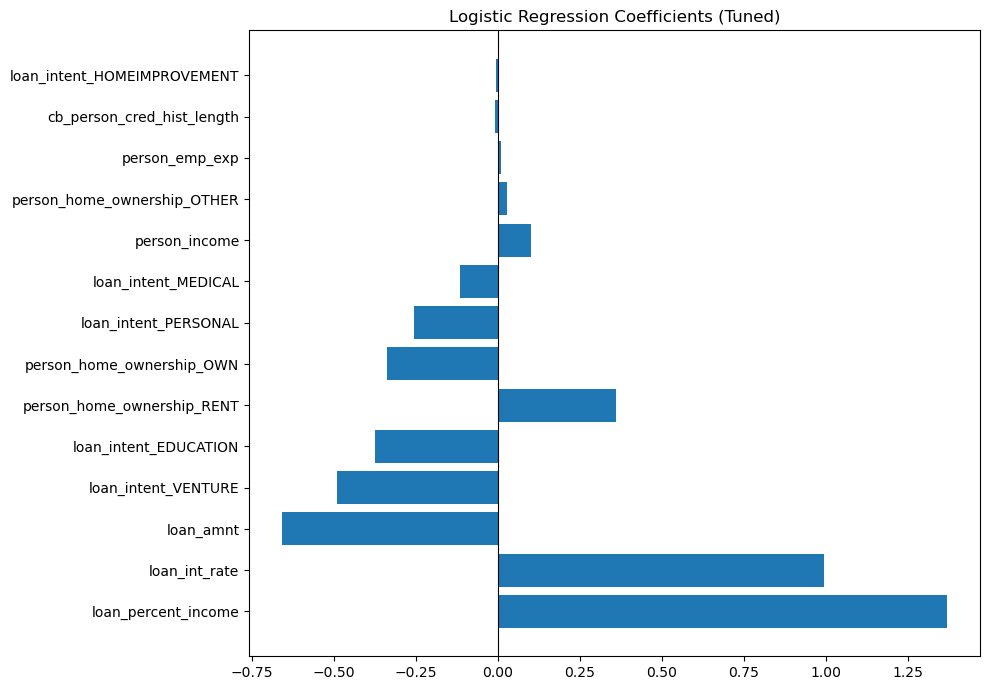


=== Feature importance: RF vs XGB (tuned, final model) ===
                    feature  RF_importance  XGB_importance
 person_home_ownership_RENT       0.065333        0.184227
  person_home_ownership_OWN       0.014236        0.152790
        loan_intent_VENTURE       0.013787        0.099263
        loan_percent_income       0.196240        0.088618
              loan_int_rate       0.243278        0.085942
loan_intent_HOMEIMPROVEMENT       0.013206        0.078018
              person_income       0.208136        0.077194
      loan_intent_EDUCATION       0.011488        0.046326
                  loan_amnt       0.105539        0.039832
        loan_intent_MEDICAL       0.009560        0.038743
       loan_intent_PERSONAL       0.009045        0.038391
person_home_ownership_OTHER       0.001137        0.033843
 cb_person_cred_hist_length       0.051550        0.018818
             person_emp_exp       0.057466        0.017995


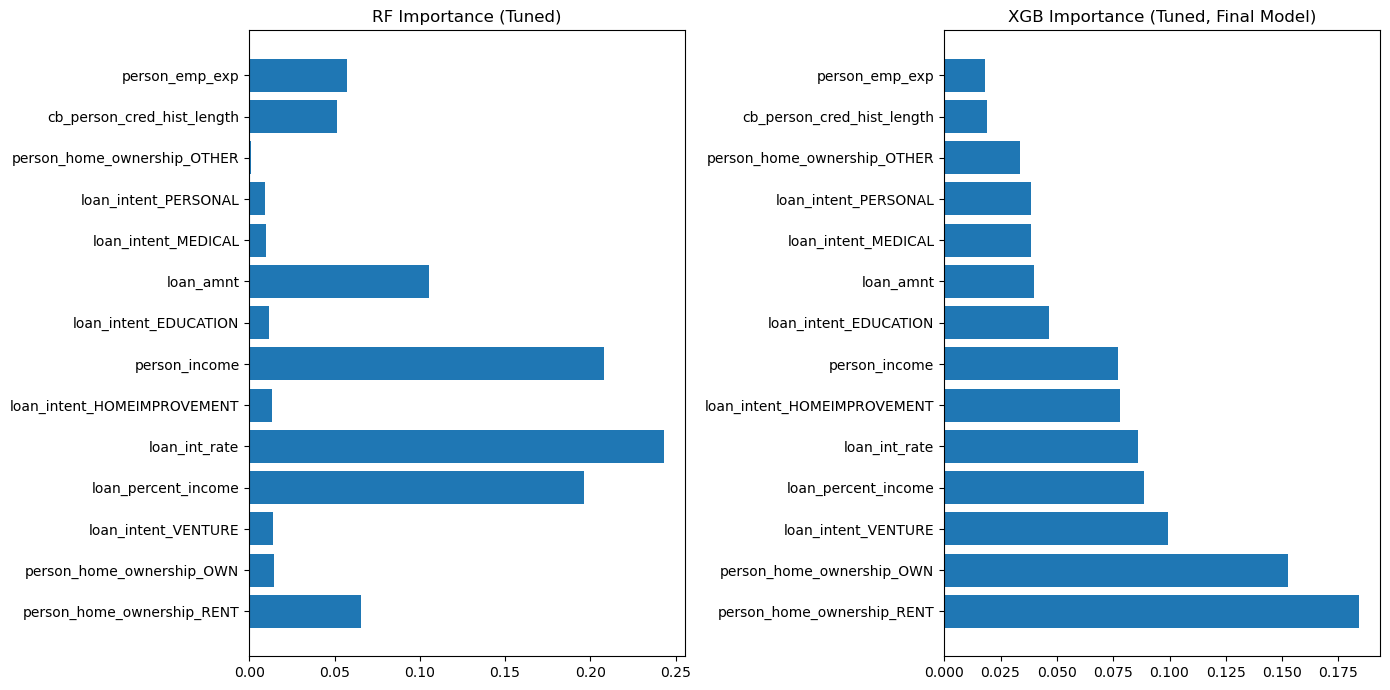

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

models = joblib.load('trained_models.pkl')
X_train_scaled = pd.read_csv('X_train_scaled.csv')
feature_names = X_train_scaled.columns.tolist()

# --- Logistic Regression coefficients (tuned version) ---
logreg = models['LogReg_ClassWeight_Tuned']
coefs = pd.DataFrame({'feature': feature_names, 'coefficient': logreg.coef_[0]}).sort_values('coefficient', key=abs, ascending=False)
print("=== Logistic Regression coefficients (tuned) ===")
print(coefs.to_string(index=False))

plt.figure(figsize=(10, 7))
plt.barh(coefs['feature'], coefs['coefficient'])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients (Tuned)')
plt.tight_layout(); plt.savefig('logreg_coefficients_final.png', dpi=120); plt.show()

# --- Feature importance: RF and XGB (tuned versions, the actual final model) ---
rf = models['RF_ClassWeight_Tuned']
xgb = models['XGB_ClassWeight_Tuned']

importance_df = pd.DataFrame({
    'feature': feature_names,
    'RF_importance': rf.feature_importances_,
    'XGB_importance': xgb.feature_importances_
}).sort_values('XGB_importance', ascending=False)

print("\n=== Feature importance: RF vs XGB (tuned, final model) ===")
print(importance_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].barh(importance_df['feature'], importance_df['RF_importance']); axes[0].set_title('RF Importance (Tuned)')
axes[1].barh(importance_df['feature'], importance_df['XGB_importance']); axes[1].set_title('XGB Importance (Tuned, Final Model)')
plt.tight_layout(); plt.savefig('feature_importance_final.png', dpi=120); plt.show()


In [11]:
import pandas as pd
import numpy as np

# person_gender / person_education were excluded from the model (Step 4.5 feature
# selection), but we saved the full encoded test set earlier — pull the demographic
# columns back out of that, purely to check outcomes, not to feed the model.
X_test_raw_full = pd.read_csv('X_test_raw_full.csv').reset_index(drop=True)
final_preds = pd.read_csv('final_predictions.csv').reset_index(drop=True)

assert len(X_test_raw_full) == len(final_preds), "Row count mismatch!"

df_fair = pd.concat([X_test_raw_full, final_preds], axis=1)

df_fair['gender'] = np.where(df_fair['person_gender_male'] == 1, 'male', 'female')

def get_education(row):
    if row['person_education_Bachelor'] == 1: return 'Bachelor'
    if row['person_education_High School'] == 1: return 'High School'
    if row['person_education_Master'] == 1: return 'Master'
    if row['person_education_Doctorate'] == 1: return 'Doctorate'
    return 'Associate'

df_fair['education'] = df_fair.apply(get_education, axis=1)

def fairness_report(df, group_col):
    rows = []
    for grp, sub in df.groupby(group_col):
        tn = ((sub['y_true']==0)&(sub['y_pred']==0)).sum()
        fp = ((sub['y_true']==0)&(sub['y_pred']==1)).sum()
        fn = ((sub['y_true']==1)&(sub['y_pred']==0)).sum()
        tp = ((sub['y_true']==1)&(sub['y_pred']==1)).sum()
        rows.append({'group': grp, 'n': len(sub), 'approval_rate': (sub['y_pred']==0).mean(),
            'false_positive_rate': fp/(fp+tn) if fp+tn>0 else np.nan,
            'false_negative_rate': fn/(fn+tp) if fn+tp>0 else np.nan})
    return pd.DataFrame(rows)

print("=== Fairness: gender ===")
print(fairness_report(df_fair, 'gender').to_string(index=False))

print("\n=== Fairness: education ===")
print(fairness_report(df_fair, 'education').to_string(index=False))


=== Fairness: gender ===
 group    n  approval_rate  false_positive_rate  false_negative_rate
female 4000       0.694500             0.153846             0.135831
  male 4999       0.679536             0.154944             0.123037

=== Fairness: education ===
      group    n  approval_rate  false_positive_rate  false_negative_rate
  Associate 2375       0.690526             0.151334             0.150558
   Bachelor 2696       0.688056             0.156427             0.120690
  Doctorate  105       0.742857             0.095238             0.095238
High School 2415       0.681988             0.153143             0.128159
     Master 1408       0.678267             0.162579             0.107492


In [12]:
import pandas as pd

results_df = pd.read_csv('model_comparison_results_tuned.csv')
print("=== FINAL COMPARISON — all 18 models ===")
print(results_df.sort_values('roc_auc', ascending=False).to_string(index=False))

print("""
====================================================================
CONCLUSION
====================================================================

WINNING MODEL: XGB_ClassWeight_Tuned, decision threshold = 0.35
  - ROC-AUC: 0.938 (highest of all 18 models tested)
  - Recall (defaulters caught): 87.2% (1,743 / 2,000)
  - Precision: 62% 
  - Chosen for recall, not raw accuracy: RF_ClassWeight_Tuned had similar
    accuracy but only 67% recall — would miss ~33% more real defaulters,
    which is the costlier mistake in a lending context (Step 8 reasoning).

WHY THIS MODEL, IN ORDER OF DECISION POINTS:
  1. Removed previous_loan_defaults_on_file — proven target leakage
     (zero exceptions across 22,858 rows; not a real-world relationship).
  2. Removed person_age — redundant with person_emp_exp (VIF=14, corr=0.95).
  3. Formal feature selection (SelectKBest + RFE + Lasso, 2-of-3 vote)
     dropped credit_score, person_gender, and all education dummies —
     confirmed by 3 independent methods, not just visual inspection.
     Dropping these 6 features did NOT hurt performance (AUC held or
     slightly improved vs. the full 20-feature version).
  4. Compared SMOTE vs class_weight='balanced' across 5 algorithms —
     class_weight edged out SMOTE for tree models; nearly identical
     for LogReg/SVM.
  5. Hyperparameter tuning (RandomizedSearchCV, 5-fold CV) applied to
     all 9 models. XGBoost improved modestly; KNN improved substantially
     (+0.028 AUC); SVM slightly WORSENED after tuning (-0.001) — reported
     honestly rather than omitted.
  6. Threshold lowered from 0.5 to 0.35 — deliberate business tradeoff:
     in lending, missing a real defaulter costs more than rejecting a
     safe applicant, so recall was prioritized over precision.

INTERPRETABILITY:
  - loan_percent_income and loan_int_rate are the most consistent
    predictors across every version of this analysis (simple stats
    tests, LogReg coefficients, tree importance) — the most robust
    finding in the whole project.
  - Tree models (RF/XGB) place unexpectedly high weight on home
    ownership status (RENT/OWN) — a nuance LogReg's linear view
    doesn't fully capture, likely due to feature interactions.
  - credit_score was formally dropped by feature selection — despite
    intuition, it added little once loan_percent_income and
    loan_int_rate were already in the model.

FAIRNESS:
  - No meaningful disparity by gender (approval rate, FPR, FNR all
    within ~1.5 points across female/male).
  - No meaningful disparity by education, except a statistically
    inconclusive signal in the Doctorate subgroup (n=105 — too small
    to draw a real conclusion from).
====================================================================
""")

=== FINAL COMPARISON — all 18 models ===
                   model  accuracy  precision  recall       f1  roc_auc
   XGB_ClassWeight_Tuned  0.896655   0.747685  0.8075 0.776442 0.938477
         XGB_ClassWeight  0.892210   0.735806  0.8035 0.768164 0.936084
         XGB_SMOTE_Tuned  0.914213   0.867665  0.7245 0.789646 0.935440
               XGB_SMOTE  0.911212   0.870908  0.7050 0.779221 0.931864
    RF_ClassWeight_Tuned  0.911546   0.908412  0.6695 0.770869 0.930345
          RF_ClassWeight  0.911657   0.910702  0.6680 0.770695 0.929077
          RF_SMOTE_Tuned  0.900767   0.800652  0.7370 0.767508 0.923872
                RF_SMOTE  0.898655   0.796296  0.7310 0.762252 0.923358
         SVM_ClassWeight  0.832426   0.593465  0.7810 0.674439 0.888338
               SVM_SMOTE  0.832648   0.595367  0.7710 0.671895 0.887854
   SVM_ClassWeight_Tuned  0.841205   0.615916  0.7585 0.679812 0.887289
         SVM_SMOTE_Tuned  0.842427   0.619067  0.7565 0.680918 0.886821
         KNN_SMOTE_Tune

In [13]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

selected_features = pd.read_csv('selected_features.csv')['0'].tolist()
X_train_scaled = pd.read_csv('X_train_scaled.csv')  # already trimmed to the 14 selected features

X_vif = add_constant(X_train_scaled)
vif_data = pd.DataFrame({'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]})
vif_data = vif_data[vif_data['feature'] != 'const']

print("=== VIF on final 14 selected features (the actual modeling set) ===")
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))
print("\nAll values should be under 5 — if any aren't, that's a redundancy that SelectKBest/RFE/Lasso wouldn't have caught, since none of them specifically test for multicollinearity.")

=== VIF on final 14 selected features (the actual modeling set) ===
                    feature      VIF
             person_emp_exp 3.395822
 cb_person_cred_hist_length 3.352565
                  loan_amnt 2.255637
        loan_percent_income 2.217885
      loan_intent_EDUCATION 1.828706
        loan_intent_MEDICAL 1.796037
        loan_intent_VENTURE 1.765411
       loan_intent_PERSONAL 1.721742
loan_intent_HOMEIMPROVEMENT 1.508684
              person_income 1.492476
 person_home_ownership_RENT 1.256355
  person_home_ownership_OWN 1.138938
              loan_int_rate 1.049965
person_home_ownership_OTHER 1.005246

All values should be under 5 — if any aren't, that's a redundancy that SelectKBest/RFE/Lasso wouldn't have caught, since none of them specifically test for multicollinearity.


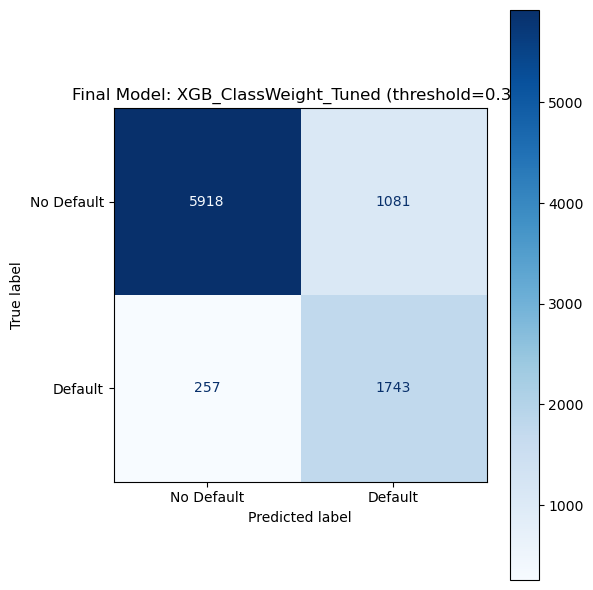

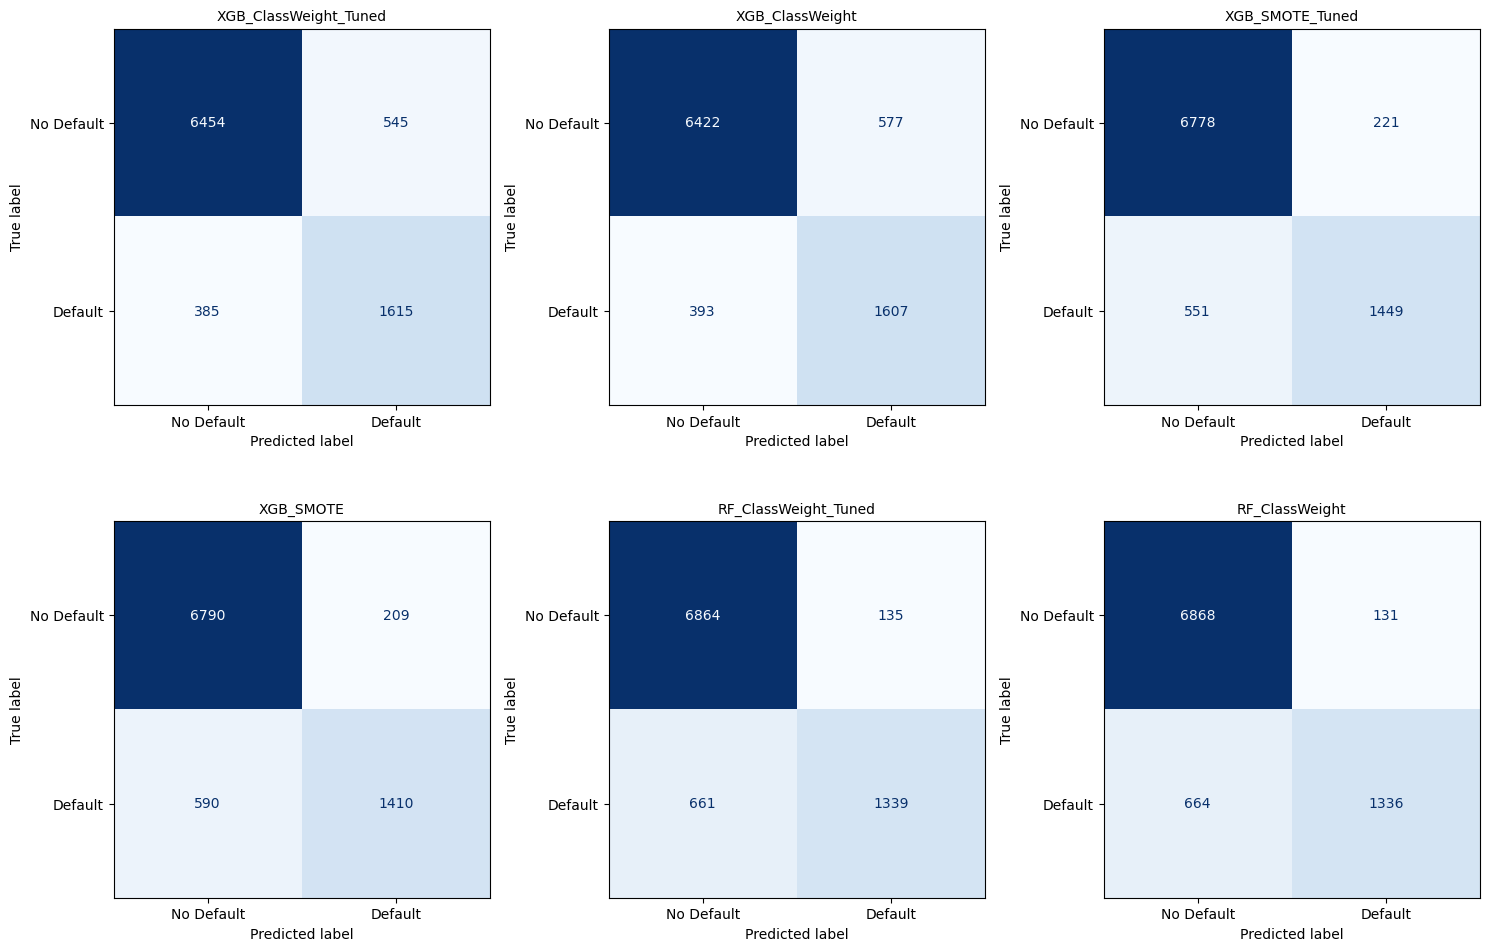

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib

models = joblib.load('trained_models.pkl')
X_test_scaled = pd.read_csv('X_test_scaled.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

# ============================================================
# 1. Final model — single clean confusion matrix at threshold=0.35
# ============================================================
best_model = models['XGB_ClassWeight_Tuned']
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred_final = (y_proba >= 0.35).astype(int)

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Final Model: XGB_ClassWeight_Tuned (threshold=0.35)')
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150)
plt.show()

# ============================================================
# 2. Comparison grid — top 6 models by ROC-AUC, at default 0.5 threshold
# ============================================================
results_df = pd.read_csv('model_comparison_results_tuned.csv').sort_values('roc_auc', ascending=False)
top6 = results_df.head(6)['model'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, name in enumerate(top6):
    model = models[name]
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=axes.flat[i], cmap='Blues', values_format='d', colorbar=False)
    axes.flat[i].set_title(name, fontsize=10)
plt.tight_layout()
plt.savefig('confusion_matrices_top6.png', dpi=150)
plt.show()

NameError: name 'RocCurveDisplay' is not defined

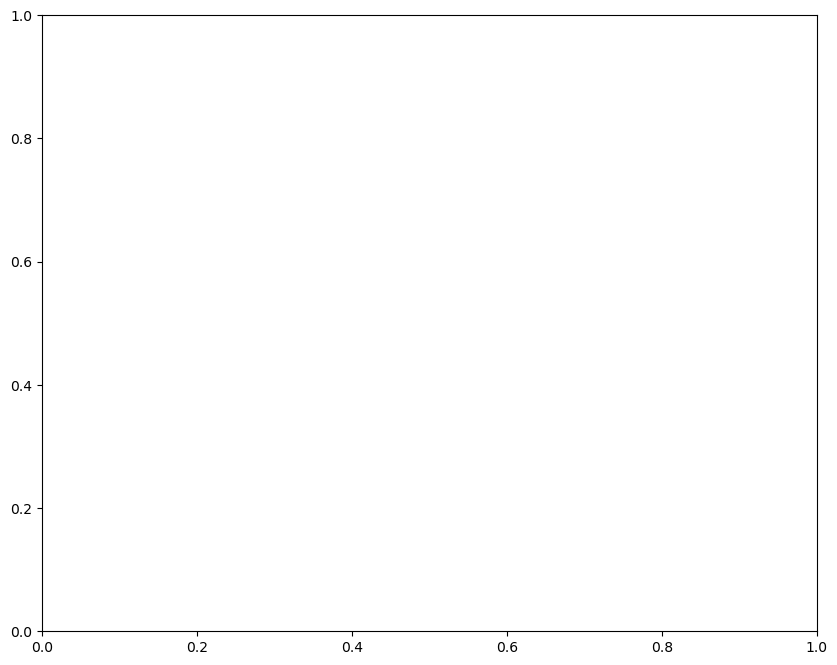

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('roc_curves_all_models.png', dpi=120)
plt.show()

In [16]:
# --- Summary comparison table ---
results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
print("\n\n" + "="*60)
print("SUMMARY — all models, sorted by ROC-AUC")
print("="*60)
print(results_df.to_string(index=False))
results_df.to_csv('model_comparison_results.csv', index=False)



SUMMARY — all models, sorted by ROC-AUC
                   model  accuracy  precision  recall       f1  roc_auc
   XGB_ClassWeight_Tuned  0.896655   0.747685  0.8075 0.776442 0.938477
         XGB_ClassWeight  0.892210   0.735806  0.8035 0.768164 0.936084
         XGB_SMOTE_Tuned  0.914213   0.867665  0.7245 0.789646 0.935440
               XGB_SMOTE  0.911212   0.870908  0.7050 0.779221 0.931864
    RF_ClassWeight_Tuned  0.911546   0.908412  0.6695 0.770869 0.930345
          RF_ClassWeight  0.911657   0.910702  0.6680 0.770695 0.929077
          RF_SMOTE_Tuned  0.900767   0.800652  0.7370 0.767508 0.923872
                RF_SMOTE  0.898655   0.796296  0.7310 0.762252 0.923358
         SVM_ClassWeight  0.832426   0.593465  0.7810 0.674439 0.888338
               SVM_SMOTE  0.832648   0.595367  0.7710 0.671895 0.887854
   SVM_ClassWeight_Tuned  0.841205   0.615916  0.7585 0.679812 0.887289
         SVM_SMOTE_Tuned  0.842427   0.619067  0.7565 0.680918 0.886821
         KNN_SMOTE_Tun

In [17]:
from sklearn.metrics imports RocCurveDisplay

fig, ax = plt.subplots(figsize=(10, 8))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('roc_curves_all_models.png', dpi=120)
plt.show()

SyntaxError: invalid syntax (3942053650.py, line 1)

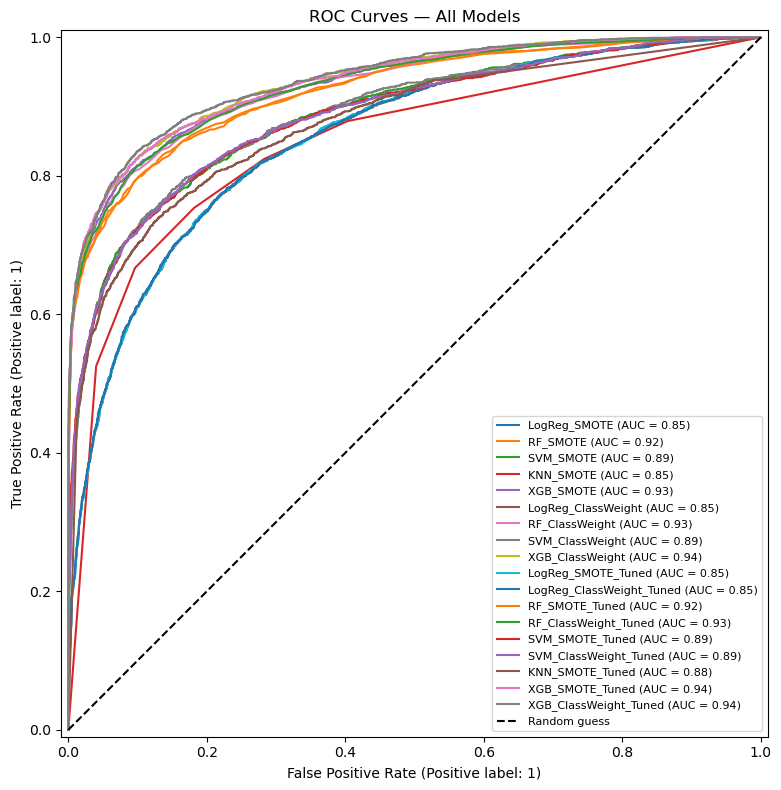

In [18]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(10, 8))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('roc_curves_all_models.png', dpi=120)
plt.show()